# Step 1: Importing the dependencies


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.cluster as KMeans

# Step 2: Loading the data 

In [19]:
df = pd.read_csv("OnlineRetail.csv", encoding="latin1")

In [20]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


# Step 3: Exploratory Data Analysis (EDA)

# Data Quality Check

In [21]:
df.shape

(541909, 8)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [23]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [27]:
df.nunique()

InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64

The dataset is transaction-level with 4,372 unique customers, 25,900 invoices, and 38 countries. Since clustering is customer-based, we will aggregate transaction data into customer-level features using RFM analysis before applying K-Means.

In [26]:
#check missing values:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

# Data Cleaning (Wrangling)

In [31]:
# dropping CustomerID
df= df.dropna(subset=["CustomerID"])

We can't group customers without ID, and we also can't do clustering without it.So we removed it.

In [33]:
# removing cacellations invoice starting w "C"
df = df[~df["InvoiceNo"].astype(str).str.startswith('C')]

In [34]:
# removing negative quantities
df= df[df["Quantity"]>0]
df=df[df["UnitPrice"]>0]

In [37]:
df.shape

(397884, 8)

In [38]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,397884.000000,397884.000000,397884.000000
mean,12.988238,3.116488,15294.423453
std,179.331775,22.097877,1713.141560
min,1.000000,0.001000,12346.000000
25%,2.000000,1.250000,13969.000000
50%,6.000000,1.950000,15159.000000
75%,12.000000,3.750000,16795.000000
max,80995.000000,8142.750000,18287.000000


Removing refunds and cancelled transactions, which do not reflect actual perchasing behavior.


In [40]:
# datatype conversion
df["InvoiceDate"]=pd.to_datetime(df["InvoiceDate"])
df["CustomerID"]=df["CustomerID"].astype(int)

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  int64         
 7   Country      397884 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 27.3+ MB


In [42]:
df["InvoiceNo"]=df["InvoiceNo"].astype(int)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  int64         
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  int64         
 7   Country      397884 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(3)
memory usage: 27.3+ MB


In [44]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


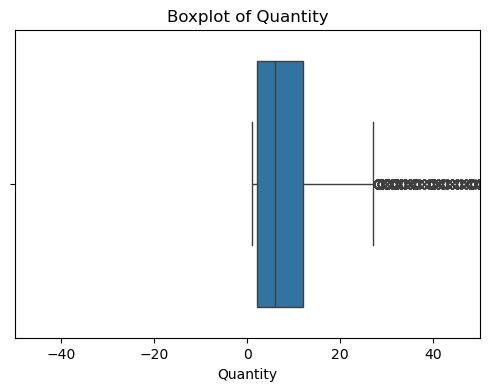

In [49]:
# outliers detection
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Quantity"])
plt.xlim(-50, 50)
plt.title("Boxplot of Quantity")
plt.show()

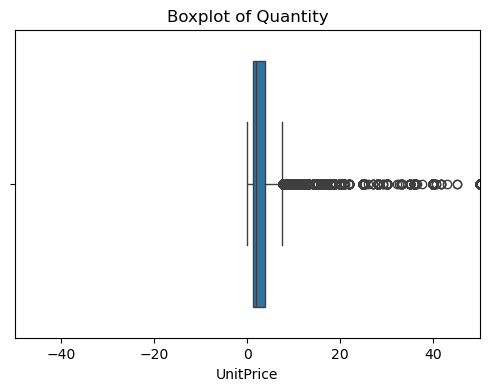

In [53]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["UnitPrice"])
plt.xlim(-50, 50)
plt.title("Boxplot of Quantity")
plt.show()

These large values are actually useful because they help define VIP customers, bulk buyers and low-value customers.

# Step 4: Feature Engineering (RFM Model)

In [55]:
# Transaction Value
df["TotalPrice"]=df["Quantity"]* df["UnitPrice"]

In [61]:
# monetary
monetary = df.groupby("CustomerID")["TotalPrice"].sum().reset_index()
monetary.columns=["CustomerID","Monetary"]
monetary

,CustomerID,Monetary
0,12346,77183.60
1,12347,4310.00
2,12348,1797.24
3,12349,1757.55
4,12350,334.40
...,...,...
4333,18280,180.60
4334,18281,80.82
4335,18282,178.05
4336,18283,2094.88


In [63]:
# frequency
frequency =df.groupby("CustomerID")["InvoiceNo"].nunique().reset_index()
frequency.columns=["CustomerID","Frequency"]
frequency

,CustomerID,Frequency
0,12346,1
1,12347,7
2,12348,4
3,12349,1
4,12350,1
...,...,...
4333,18280,1
4334,18281,1
4335,18282,2
4336,18283,16


In [65]:
#Recency
snapshot_date = df["InvoiceDate"].max()

In [67]:
# calculate the last purchase
recency =df.groupby('CustomerID')["InvoiceDate"].max().reset_index()
recency.columns=["CustomerID","LastPurchaseDate"]
recency

,CustomerID,LastPurchaseDate
0,12346,2011-01-18 10:01:00
1,12347,2011-12-07 15:52:00
2,12348,2011-09-25 13:13:00
3,12349,2011-11-21 09:51:00
4,12350,2011-02-02 16:01:00
...,...,...
4333,18280,2011-03-07 09:52:00
4334,18281,2011-06-12 10:53:00
4335,18282,2011-12-02 11:43:00
4336,18283,2011-12-06 12:02:00


In [72]:
recency['Recency'] = (snapshot_date - recency['LastPurchaseDate']).dt.days

In [74]:
# merging
rf = monetary.merge(frequency, on="CustomerID")
rf = rf.merge(recency[["CustomerID","Recency"]],on="CustomerID")
rf

,CustomerID,Monetary,Frequency,Recency
0,12346,77183.60,1,325
1,12347,4310.00,7,1
2,12348,1797.24,4,74
3,12349,1757.55,1,18
4,12350,334.40,1,309
...,...,...,...,...
4333,18280,180.60,1,277
4334,18281,80.82,1,180
4335,18282,178.05,2,7
4336,18283,2094.88,16,3


In [76]:
rf.describe()

,CustomerID,Monetary,Frequency,Recency
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,2054.266460,4.272015,91.536422
std,1721.808492,8989.230441,7.697998,100.014169
min,12346.000000,3.750000,1.000000,0.000000
25%,13813.250000,307.415000,1.000000,17.000000
50%,15299.500000,674.485000,2.000000,50.000000
75%,16778.750000,1661.740000,5.000000,141.000000
max,18287.000000,280206.020000,209.000000,373.000000


The values are not similar in scale the monetary is too much

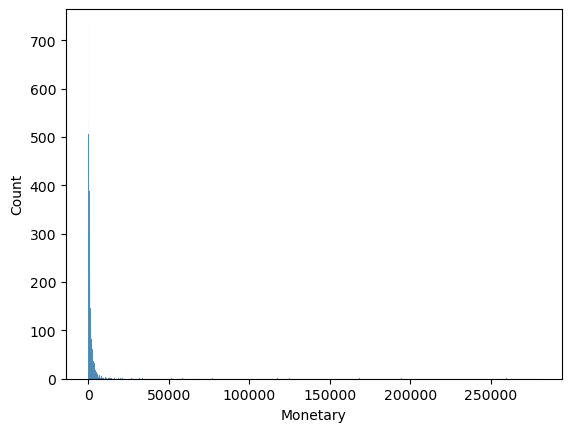

In [80]:
# visualizaing the RFM disctribution

sns.histplot(rf["Monetary"])
plt.show()

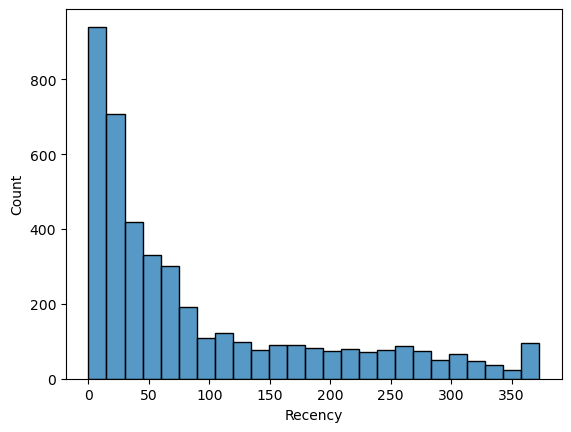

In [83]:
sns.histplot(rf["Recency"])
plt.show()

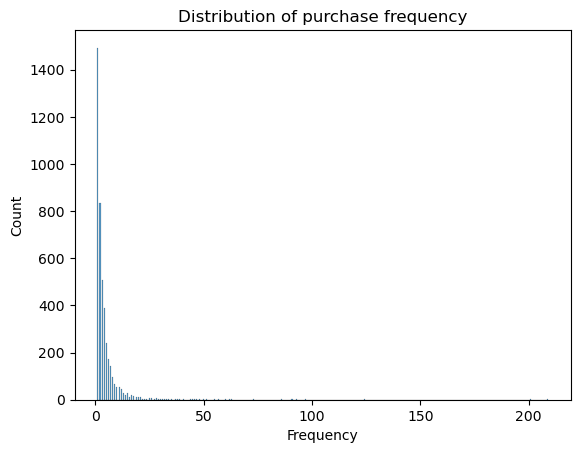

In [84]:
sns.histplot(rf["Frequency"])
plt.title("Distribution of purchase frequency")
plt.show()

In [87]:
rf[["Monetary","Frequency","Recency"]].describe()

,Monetary,Frequency,Recency
count,4338.000000,4338.000000,4338.000000
mean,2054.266460,4.272015,91.536422
std,8989.230441,7.697998,100.014169
min,3.750000,1.000000,0.000000
25%,307.415000,1.000000,17.000000
50%,674.485000,2.000000,50.000000
75%,1661.740000,5.000000,141.000000
max,280206.020000,209.000000,373.000000


The monetary is highly right skewed so if we don't standardize it the algorithm will become obsessed with monetary because its values are much larger than others. 

# Step 5: Standardization

In [89]:
# creating a feature matrix
X = rf[["Monetary","Frequency","Recency"]]

In [91]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() 
x_scaled = scaler.fit_transform(X)

In [93]:
x_scaled.shape

(4338, 3)

In [99]:
X_scaled_df = pd.DataFrame(
    x_scaled,
    columns=['Monetary', 'Frequency', 'Recency']
)

X_scaled_df.describe()

,Monetary,Frequency,Recency
count,4.338000e+03,4.338000e+03,4.338000e+03
mean,1.801745e-17,1.801745e-17,2.702618e-17
std,1.000115e+00,1.000115e+00,1.000115e+00
min,-2.281344e-01,-4.250965e-01,-9.153401e-01
25%,-1.943495e-01,-4.250965e-01,-7.453445e-01
50%,-1.535104e-01,-2.951776e-01,-4.153533e-01
75%,-4.367134e-02,9.457903e-02,4.946227e-01
max,3.094634e+01,2.659803e+01,2.814561e+00


# Step 6: Elbow method

In [102]:
# WCSS = within cluster sum of squares, how tighly packed the custoomers are inside clusters

from sklearn.cluster import KMeans
wcss = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(x_scaled)

    wcss.append(kmeans.inertia_)

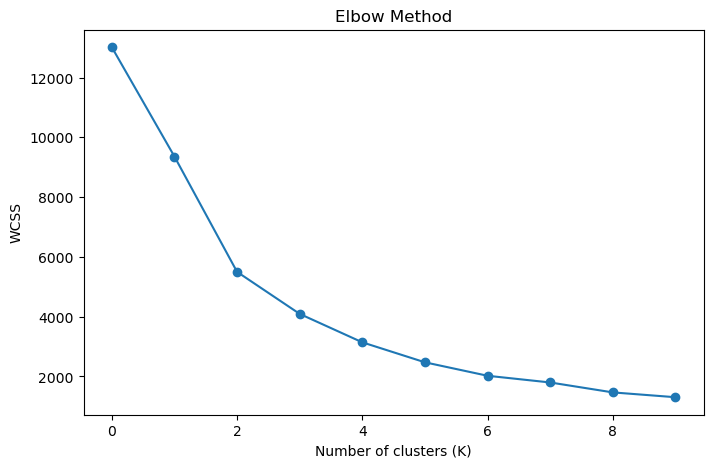

In [105]:
# plot elbow curve 
plt.figure(figsize=(8,5))
plt.plot(wcss,marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of clusters (K)")
plt.ylabel("WCSS")

plt.show()

Elbow Method Result:
The optimal number of clusters (K) is 2,because the WCSS curve shows a clear bend at K = 2,
 after which the improvement in WCSS starts to slow down significantly.

In [113]:
kmeans = KMeans(n_clusters = 2, random_state=42)
kmeans.fit(x_scaled)

KMeans(n_clusters=2, random_state=42)

In [114]:
rf["Cluster"]=kmeans.labels_
rf["Cluster"].value_counts()

Cluster
0    3237
1    1101
Name: count, dtype: int64

In [116]:
rf.groupby("Cluster")[["Monetary","Frequency","Recency"]].mean()

,Monetary,Frequency,Recency
Cluster,,,
0,2550.512926,5.186284,39.610442
1,595.274806,1.584015,244.201635


In [118]:
rf["Cluster"]=rf["Cluster"].map({
    0:"Active",
    1:"Inactive"
})

K-Means clustering with K=2 successfully segmented customers into two distinct groups: high-value active customers and low-value inactive customers. Cluster 0 represents loyal customers with higher spending and frequent recent purchases, while Cluster 1 represents dormant customers with low engagement and low monetary value.